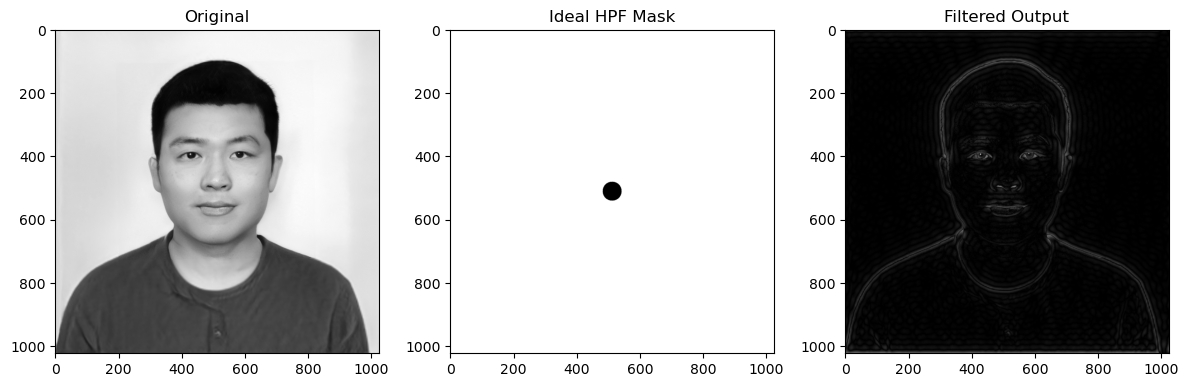

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def ideal_high_pass_filter(shape, D0):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), np.uint8)
    for u in range(rows):
        for v in range(cols):
            if np.sqrt((u - crow)**2 + (v - ccol)**2) <= D0:
                mask[u, v] = 0
    return mask

def apply_filter(img, filter_mask):
    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft)
    filtered = dft_shift * filter_mask
    back_ishift = np.fft.ifftshift(filtered)
    img_back = np.fft.ifft2(back_ishift)
    return np.abs(img_back)

img_path = r"D:\AP22110010458\digital-image-preprocessing\assets\photo.jpg"
img = cv2.imread(img_path, 0)

if img is None:
    raise FileNotFoundError(f"Image not found at: {img_path}")

D0 = 30  # Cutoff frequency
mask = ideal_high_pass_filter(img.shape, D0)
filtered_img = apply_filter(img, mask)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img, cmap='gray'), plt.title("Original")
plt.subplot(1, 3, 2), plt.imshow(mask, cmap='gray'), plt.title("Ideal HPF Mask")
plt.subplot(1, 3, 3), plt.imshow(filtered_img, cmap='gray'), plt.title("Filtered Output")
plt.tight_layout()
plt.show()
